In [369]:
import os
import json
import numpy as np
import pandas as pd
import datetime
# Base results directory
BASE_DIR = '/home/datzeni/OCL_TS/results_sens_analysis'
i = 1

# %% [markdown]
# ## 2. Collect all records

# %%
records = []

# iterate subdirectories
for root, dirs, files in os.walk(BASE_DIR):
    if 'args.json' in files and 'metrics.npy' in files:
        # 1. parse the folder basename
        folder = os.path.basename(root)
        parts = folder.split('_')
        # assume last 6 parts are [YYYY,MM,DD,HH,MM,<run_id>]
        date_str = '_'.join(parts[-6:-1])
        timestamp = datetime.datetime.strptime(date_str, '%Y_%m_%d_%H_%M')
        
        # 2. load args & metrics
        with open(os.path.join(root, 'args.json'), 'r') as f:
            args = json.load(f)
        metrics = np.load(os.path.join(root, 'metrics.npy'))
        mae = metrics[:i, 0].mean()
        mae_sd = metrics[:i, 0].std()
        exp_time = metrics[:i, 5].mean()

        if len(metrics[:i, 0]) != len(set(metrics[:i, 0])):
            print(f"Warning: Duplicate MAE values found in {root}.")

        #Load predictions and true values 
        preds = np.load(os.path.join(root, 'preds.npy'))
        trues = np.load(os.path.join(root, 'trues.npy'))   

        #Compute the MAE of the naive predictor (predicting the last observed value)
        naive_mae = np.mean(np.abs(trues[:i] - np.roll(trues[:i], shift=1, axis=1)))
        mase = metrics[:i, 0] / naive_mae
        mase_sd = mase.std()
        mase = mase.mean()
        mse = metrics[:i,1].mean()

        
        # 3. build record, including the parsed timestamp
        rec = {
            'method':          args.get('method'),
            'data':            args.get('data'),
            'online_lr':    args.get('online_lr'),
            'deg_f':           args.get('deg_f'),
            'MASE':             mase,
            'MASE_sd':             mase_sd,
            'run_timestamp':   timestamp,              # new
            'run_date':        timestamp.date(),        # if you only care about the date
            'exp_time':        exp_time,
            'NatSR_regul':    args.get('NatSR_regul'),
            'NatSR_alpha_ema':    args.get('NatSR_alpha_ema'),
            'pred_len': args.get('pred_len'),
            'NatSR_alpha_ema_grad': args.get('NatSR_alpha_ema_grad'),
            'MSE': mse,
            'pred_len': args.get('pred_len'),
            'replay_buff_size': args.get("replay_buff_size"),

        }
        records.append(rec)
# 4. DataFrame
df = pd.DataFrame.from_records(records)
df["deg_f"] = df["deg_f"].astype(int)
# 5. Pivot including the date
table = df.pivot_table(
    index=['method', 'online_lr', 'pred_len', 'deg_f', 'NatSR_regul', 'NatSR_alpha_ema', 'replay_buff_size'],
    columns='data',
    values=['MASE', 'MASE_sd', 'exp_time', 'MSE'],
).sort_index()

display(table)


MASE  \
data                                                                                 ETTh1   
method online_lr pred_len deg_f NatSR_regul NatSR_alpha_ema replay_buff_size                 
natsr  0.093018  24       10    0.140542    0.554897        8                 9.045140e-01   
                          25    0.140542    0.554897        8                 9.025141e-01   
                          50    0.010000    0.554897        8                 9.689058e+08   
                                0.140542    0.100000        8                 9.107346e-01   
                                            0.300000        8                 9.037466e-01   
                                            0.554897        2                 9.325892e-01   
                                                            4                 9.230662e-01   
                                                            8                 9.124201e-01   
                                                            16                8.994945e-01   
                                                            32                9.031530e-01   
                                            0.700000        8                 9.047013e-01   
                                            0.990000        8                 9.107947e-01   
                                0.500000    0.554897        8                 9.357422e-01   
                                0.900000    0.554897        8                 9.657647e-01   
                                1.500000    0.554897        8                 1.010277e+00   
                          250   0.140542    0.554897        8                 9.043936e-01   
                          500   0.140542    0.554897        8                 9.102577e-01   

                                                                                        \
data                                                                             ETTm1   
method online_lr pred_len deg_f NatSR_regul NatSR_alpha_ema replay_buff_size             
natsr  0.093018  24       10    0.140542    0.554897        8                 1.089327   
                          25    0.140542    0.554897        8                 1.083990   
                          50    0.010000    0.554897        8                      NaN   
                                0.140542    0.100000        8                 1.081953   
                                            0.300000        8                 1.077237   
                                            0.554897        2                 1.092493   
                                                            4                 1.095218   
                                                            8                 1.078377   
                                                            16                1.078635   
                                                            32                1.077419   
                                            0.700000        8                 1.080529   
                                            0.990000        8                 1.091755   
                                0.500000    0.554897        8                 1.108736   
                                0.900000    0.554897        8                 1.156958   
                                1.500000    0.554897        8                 1.232040   
                          250   0.140542    0.554897        8                 1.077619   
                          500   0.140542    0.554897        8                 1.075259   

                                                                                        \
data                                                                               WTH   
method online_lr pred_len deg_f NatSR_regul NatSR_alpha_ema replay_buff_size             
natsr  0.093018  24       10    0.140542    0.554897        8                 1.181820   
                          25    0.140542    

In [370]:
df.head()

,method,data,online_lr,deg_f,MASE,MASE_sd,run_timestamp,run_date,exp_time,NatSR_regul,NatSR_alpha_ema,pred_len,NatSR_alpha_ema_grad,MSE,replay_buff_size
0,natsr,ETTh1,0.093018,50,0.910735,0.0,2025-11-20 00:09:00,2025-11-20,580.374381,0.140542,0.100000,24,0.9,0.238610,8
1,natsr,WTH,0.093018,50,1.189123,0.0,2025-11-20 01:55:00,2025-11-20,1303.393378,0.140542,0.300000,24,0.9,0.163195,8
2,natsr,WTH,0.093018,10,1.181820,0.0,2025-11-20 02:18:00,2025-11-20,1318.062785,0.140542,0.554897,24,0.9,0.184613,8
3,natsr,ETTm1,0.093018,50,1.156958,0.0,2025-11-20 01:45:00,2025-11-20,554.238085,0.900000,0.554897,24,0.9,0.094685,8
4,natsr,ETTm1,0.093018,500,1.075259,0.0,2025-11-20 01:26:00,2025-11-20,522.975191,0.140542,0.554897,24,0.9,0.082157,8


In [371]:
datas = df["data"].unique()
taus = df["NatSR_regul"].unique()
nus = df["deg_f"].unique()
buffs = df["replay_buff_size"].unique()
alpha_emas = df["NatSR_alpha_ema"].unique()

len(datas), len(taus), len(nus), len(buffs), len(alpha_emas)

(3, 5, 5, 5, 5)

In [372]:
df_min = []
for ind, row in df.iterrows():
    df_min.append(df[df["data"] == row["data"]]["MASE"].min())
df["MASE_diff"] = df["MASE"] - df_min
df.head()

,method,data,online_lr,deg_f,MASE,MASE_sd,run_timestamp,run_date,exp_time,NatSR_regul,NatSR_alpha_ema,pred_len,NatSR_alpha_ema_grad,MSE,replay_buff_size,MASE_diff
0,natsr,ETTh1,0.093018,50,0.910735,0.0,2025-11-20 00:09:00,2025-11-20,580.374381,0.140542,0.100000,24,0.9,0.238610,8,0.011240
1,natsr,WTH,0.093018,50,1.189123,0.0,2025-11-20 01:55:00,2025-11-20,1303.393378,0.140542,0.300000,24,0.9,0.163195,8,0.007303
2,natsr,WTH,0.093018,10,1.181820,0.0,2025-11-20 02:18:00,2025-11-20,1318.062785,0.140542,0.554897,24,0.9,0.184613,8,0.000000
3,natsr,ETTm1,0.093018,50,1.156958,0.0,2025-11-20 01:45:00,2025-11-20,554.238085,0.900000,0.554897,24,0.9,0.094685,8,0.081699
4,natsr,ETTm1,0.093018,500,1.075259,0.0,2025-11-20 01:26:00,2025-11-20,522.975191,0.140542,0.554897,24,0.9,0.082157,8,0.000000


In [373]:
main_tau = df["NatSR_regul"].mode()[0]
main_nu = df["deg_f"].mode()[0]
main_buff = df["replay_buff_size"].mode()[0]
main_alpha = df["NatSR_alpha_ema"].mode()[0]

baseline = (
    df[(df["NatSR_regul"] == main_tau) &
       (df["deg_f"] == main_nu) &
       (df["replay_buff_size"] == main_buff) &
       (df["NatSR_alpha_ema"] == main_alpha)]
    .set_index("data")["MASE"]
)

df["MASE_diff"] = df.apply(
    lambda row: row["MASE"] - baseline.get(row["data"], np.nan),
    axis=1
)
df

,method,data,online_lr,deg_f,MASE,MASE_sd,run_timestamp,run_date,exp_time,NatSR_regul,NatSR_alpha_ema,pred_len,NatSR_alpha_ema_grad,MSE,replay_buff_size,MASE_diff
0,natsr,ETTh1,0.093018,50,9.107346e-01,0.0,2025-11-20 00:09:00,2025-11-20,580.374381,0.140542,0.100000,24,0.9,2.386103e-01,8,-1.685535e-03
1,natsr,WTH,0.093018,50,1.189123e+00,0.0,2025-11-20 01:55:00,2025-11-20,1303.393378,0.140542,0.300000,24,0.9,1.631952e-01,8,3.984872e-03
2,natsr,WTH,0.093018,10,1.181820e+00,0.0,2025-11-20 02:18:00,2025-11-20,1318.062785,0.140542,0.554897,24,0.9,1.846127e-01,8,-3.317860e-03
3,natsr,ETTm1,0.093018,50,1.156958e+00,0.0,2025-11-20 01:45:00,2025-11-20,554.238085,0.900000,0.554897,24,0.9,9.468527e-02,8,7.858107e-02
4,natsr,ETTm1,0.093018,500,1.075259e+00,0.0,2025-11-20 01:26:00,2025-11-20,522.975191,0.140542,0.554897,24,0.9,8.215682e-02,8,-3.118178e-03
5,natsr,WTH,0.093018,25,1.190570e+00,0.0,2025-11-20 02:35:00,2025-11-20,1240.048067,0.140542,0.554897,24,0.9,1.622944e-01,8,5.432668e-03
6,natsr,WTH,0.093018,50,1.278228e+00,0.0,2025-11-20 03:20:00,2025-11-20,1106.662086,1.500000,0.554897,24,0.9,1.743101e-01,8,9.308987e-02
7,natsr,WTH,0.093018,500,1.210992e+00,0.0,2025-11-20 10:13:00,2025-11-20,1570.718259,0.140542,0.554897,24,0.9,1.583773e-01,8,2.585442e-02
8,natsr,ETTh1,0.093018,25,9.025141e-01,0.0,2025-11-20 00:29:00,2025-11-20,580.562479,0.140542,0.554897,24,0.9,2.368177e-01,8,-9.905959e-03
9,natsr,WTH,0.093018,50,1.223215e+00,0.0,2025-11-20 12:22:00,2025-11-20,1717.996290,0.140542,0.990000,24,0.9,1.689686e-01,8,3.807740e-02


In [374]:
emas_diff = df[["data", "NatSR_alpha_ema", "MASE_diff"]][df["NatSR_alpha_ema"] != df["NatSR_alpha_ema"].mode()[0]]
for data in datas:
    new_row = pd.DataFrame([{
    "data": data,
    "NatSR_alpha_ema": df["NatSR_alpha_ema"].mode()[0],
    "MASE_diff": 0
    }])
    emas_diff = pd.concat([emas_diff, new_row], ignore_index=True)
taus_diff = df[["data", "NatSR_regul", "MASE_diff"]][df["NatSR_regul"] != df["NatSR_regul"].mode()[0]]
for data in datas:
    new_row = pd.DataFrame([{
    "data": data,
    "NatSR_regul": df["NatSR_regul"].mode()[0],
    "MASE_diff": 0
    }])
    taus_diff = pd.concat([taus_diff, new_row], ignore_index=True)
buffs_diff = df[["data", "replay_buff_size", "MASE_diff"]][df["replay_buff_size"] != df["replay_buff_size"].mode()[0]]
for data in datas:
    new_row = pd.DataFrame([{
    "data": data,
    "replay_buff_size": df["replay_buff_size"].mode()[0],
    "MASE_diff": 0
    }])
    buffs_diff = pd.concat([buffs_diff, new_row], ignore_index=True)
nus_diff = df[["data", "deg_f", "MASE_diff"]][df["deg_f"] != df["deg_f"].mode()[0]]
for data in datas:
    new_row = pd.DataFrame([{
    "data": data,
    "deg_f": df["deg_f"].mode()[0],
    "MASE_diff": 0
    }])
    nus_diff = pd.concat([nus_diff, new_row], ignore_index=True)

In [375]:
p1 = emas_diff.pivot_table(
    index="data",
    columns="NatSR_alpha_ema",
    values="MASE_diff"
)
p1

NatSR_alpha_ema,0.100000,0.300000,0.554897,0.700000,0.990000
data,,,,,
ETTh1,-0.001686,-0.008673,0.0,-0.007719,-0.001625
ETTm1,0.003576,-0.001140,0.0,0.002152,0.013378
WTH,0.005178,0.003985,0.0,0.008767,0.038077


In [376]:
p2 = taus_diff.pivot_table(
    index="data",
    columns="NatSR_regul",
    values="MASE_diff"
)
p2

NatSR_regul,0.010000,0.140542,0.500000,0.900000,1.500000
data,,,,,
ETTh1,9.689058e+08,0.0,0.023322,0.053345,0.097857
ETTm1,NaN,0.0,0.030358,0.078581,0.153663
WTH,NaN,0.0,0.019485,0.053077,0.093090


In [377]:
p3 = buffs_diff.pivot_table(
    index="data",
    columns="replay_buff_size",
    values="MASE_diff"
)
p3

replay_buff_size,2,4,8,16,32
data,,,,,
ETTh1,0.020169,0.010646,0.0,-0.012926,-0.009267
ETTm1,0.014115,0.016841,0.0,0.000257,-0.000959
WTH,0.063493,0.025926,0.0,0.002600,0.004708


In [378]:
p4 = nus_diff.pivot_table(
    index="data",
    columns="deg_f",
    values="MASE_diff"
)
p4

deg_f,10,25,50,250,500
data,,,,,
ETTh1,-0.007906,-0.009906,0.0,-0.008026,-0.002162
ETTm1,0.010949,0.005612,0.0,-0.000758,-0.003118
WTH,-0.003318,0.005433,0.0,0.016661,0.029908


In [379]:
pivot1 = p1.add_prefix("regul_")
pivot2 = p2.add_prefix("alpha_")
pivot3 = p3.add_prefix("buffer_")
pivot4 = p4.add_prefix("degf_")

vmax = 1
combined = pd.concat([pivot1, pivot2, pivot3, pivot4], axis=1)
combined

,regul_0.1,regul_0.3,regul_0.5548965149124905,regul_0.7,regul_0.99,alpha_0.01,alpha_0.14054211103075812,alpha_0.5,alpha_0.9,alpha_1.5,buffer_2,buffer_4,buffer_8,buffer_16,buffer_32,degf_10,degf_25,degf_50,degf_250,degf_500
data,,,,,,,,,,,,,,,,,,,,
ETTh1,-0.001686,-0.008673,0.0,-0.007719,-0.001625,9.689058e+08,0.0,0.023322,0.053345,0.097857,0.020169,0.010646,0.0,-0.012926,-0.009267,-0.007906,-0.009906,0.0,-0.008026,-0.002162
ETTm1,0.003576,-0.001140,0.0,0.002152,0.013378,NaN,0.0,0.030358,0.078581,0.153663,0.014115,0.016841,0.0,0.000257,-0.000959,0.010949,0.005612,0.0,-0.000758,-0.003118
WTH,0.005178,0.003985,0.0,0.008767,0.038077,NaN,0.0,0.019485,0.053077,0.093090,0.063493,0.025926,0.0,0.002600,0.004708,-0.003318,0.005433,0.0,0.016661,0.029908


In [380]:
import pandas as pd
import numpy as np

# Example: split columns into hyperparameter groups
len_alpha, len_regul, len_buffer = 5, 5, 5
alpha_cols = combined.columns[:len_alpha]
regul_cols = combined.columns[len_alpha:len_alpha+len_regul]
buffer_cols = combined.columns[len_alpha+len_regul:len_alpha+len_regul+len_buffer]
degf_cols = combined.columns[len_alpha+len_regul+len_buffer:]

# # Create MultiIndex for columns
# combined.columns = pd.MultiIndex.from_tuples(
#     [("alpha", str(c)) for c in alpha_cols] +
#     [("regul", str(c)) for c in regul_cols] +
#     [("buffer", str(c)) for c in buffer_cols] +
#     [("deg_f", str(c)) for c in degf_cols]
# )


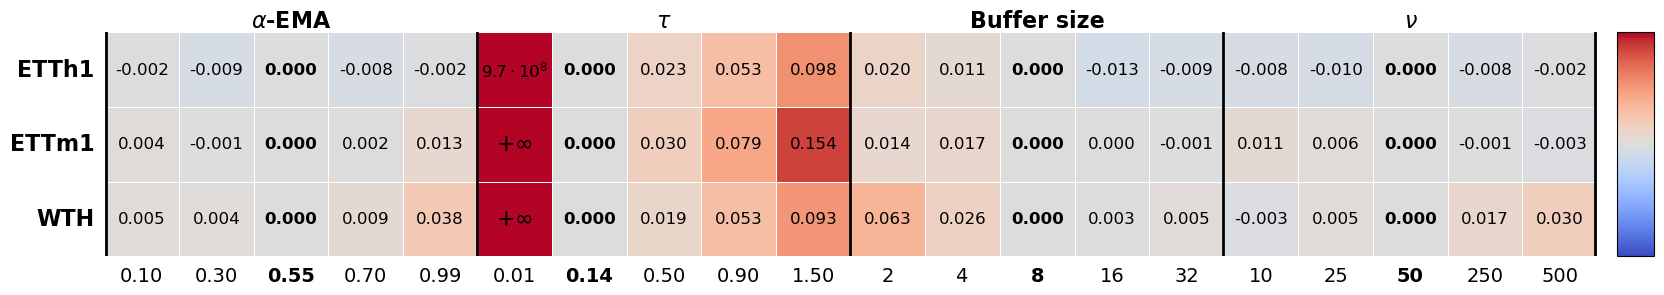

In [381]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from mpl_toolkits.axes_grid1 import make_axes_locatable

num_fontsize = 12
tick_fontsize = 14
param_fontsize = 16
cmap = "coolwarm"
vmax = 0.18
vmin = -vmax

n_rows, n_cols = combined.shape
fig_width = max(n_cols, 10)
fig_height = max(n_rows, 10)
fig, ax = plt.subplots(figsize=(fig_width, fig_height))

# Draw heatmap
sns.heatmap(
    combined.fillna(combined.max()),
    annot=False,
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
    linewidths=0.5,
    linecolor="white",
    square=True,
    ax=ax,
    cbar=False
)

# Vertical separators (thicker + lines at start and end)
group_sizes = [len(alpha_cols), len(regul_cols), len(buffer_cols), len(degf_cols)]
pos = [0] + list(np.cumsum(group_sizes))

for i, p in enumerate(pos):
    shift_first = 0.025
    shift_last = 0.03
    shift_between = 0.01
    if len(pos)-1 == i:
        ax.vlines(p-shift_last, ymin=-0.5, ymax=n_rows, color='black', linewidth=2)
    elif i == 0:
        ax.vlines(p+shift_first, ymin=-0.5, ymax=n_rows, color='black', linewidth=2)
    else:
        ax.vlines(p-shift_between, ymin=-0.5, ymax=n_rows, color='black', linewidth=2)

# Hyperparameter group labels (Greek symbols)
group_symbols = [r'$\alpha$' + "-EMA", r'$\tau$', 'Buffer size', r'$\nu$'] 
start = 0
for size, symbol in zip(group_sizes, group_symbols):
    end = start + size
    mid = (start + end) / 2
    ax.text(mid, 0, symbol, ha='center', va='bottom', fontsize=param_fontsize, color='black', fontweight=600)
    start = end

# Remove ylabel and tick lines
ax.set_ylabel('')
ax.tick_params(left=False, bottom=False)

# Safe xtick formatting
def format_col_label(x):
    try:
        x = x.split("_")[1]
        if len(x.split(".")[1]) == 0:
            return x
        return f"{float(x):.2f}"
    except:
        if isinstance(x, tuple):
            return f"{x[0]:.3f}" if isinstance(x[0], (int, float)) else str(x)
        else:
            return str(x)

ax.set_xticks(np.arange(n_cols) + 0.5)
xtick_labels = [format_col_label(x) for x in combined.columns]
ax.set_xticklabels(xtick_labels, fontsize=tick_fontsize, rotation=0)
ax.set_yticks(np.arange(n_rows) + 0.5)
ax.set_yticklabels(combined.index, fontsize=param_fontsize, rotation=0, fontweight=600)
ax.invert_yaxis()

# Columns to bold (absolute indices)
bold_cols = [
    2,                                      # third column of first group
    len(alpha_cols) + 1,                     # second column of second group
    len(alpha_cols) + len(regul_cols) + 2,   # third column of third group
    len(alpha_cols) + len(regul_cols) + len(buffer_cols) + 2, # third column of fourth group
]
bold_cols = list(set(bold_cols))

# Annotate heatmap values
for i in range(n_rows):
    for j in range(n_cols):
        val = combined.iloc[i, j]
        if pd.isna(val):
            txt = r'$+\infty$'
            fontsize = param_fontsize
        elif abs(val) >= 1e3:
            exponent = int(np.floor(np.log10(abs(val))))
            coeff = val / 10**exponent
            txt = f"${coeff:.1f} \\cdot 10^{{{exponent}}}$"
            fontsize = num_fontsize
        else:
            txt = f'{val:.3f}'
            fontsize = num_fontsize
        
        fontweight = 'bold' if j in bold_cols else 'normal'
        ax.text(j + 0.5, i + 0.5, txt, ha='center', va='center', fontsize=fontsize, fontweight=fontweight)

# Bold xtick labels for selected columns
for j, lbl in enumerate(xtick_labels):
    weight = 'bold' if j in bold_cols else 'normal'
    ax.get_xticklabels()[j].set_fontweight(weight)

# Custom colorbar
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="2.5%", pad=0.2)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=-0.2, vmax=0.2))
sm.set_array([])
cbar = plt.colorbar(sm, cax=cax)
cbar.ax.set_yticks([])

ax.set_ylim(n_rows, 0)
plt.show()
